In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Let's use a clean, professional style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif' # A more modern font choice
# What rcParams does is that this style willl be applied to all the data below like global

In [4]:
months = pd.to_datetime(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
                         '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01'])
sales = [120, 135, 160, 155, 180, 210, 230, 225, 250, 280, 290, 310]
data = pd.Series(sales, index=months)

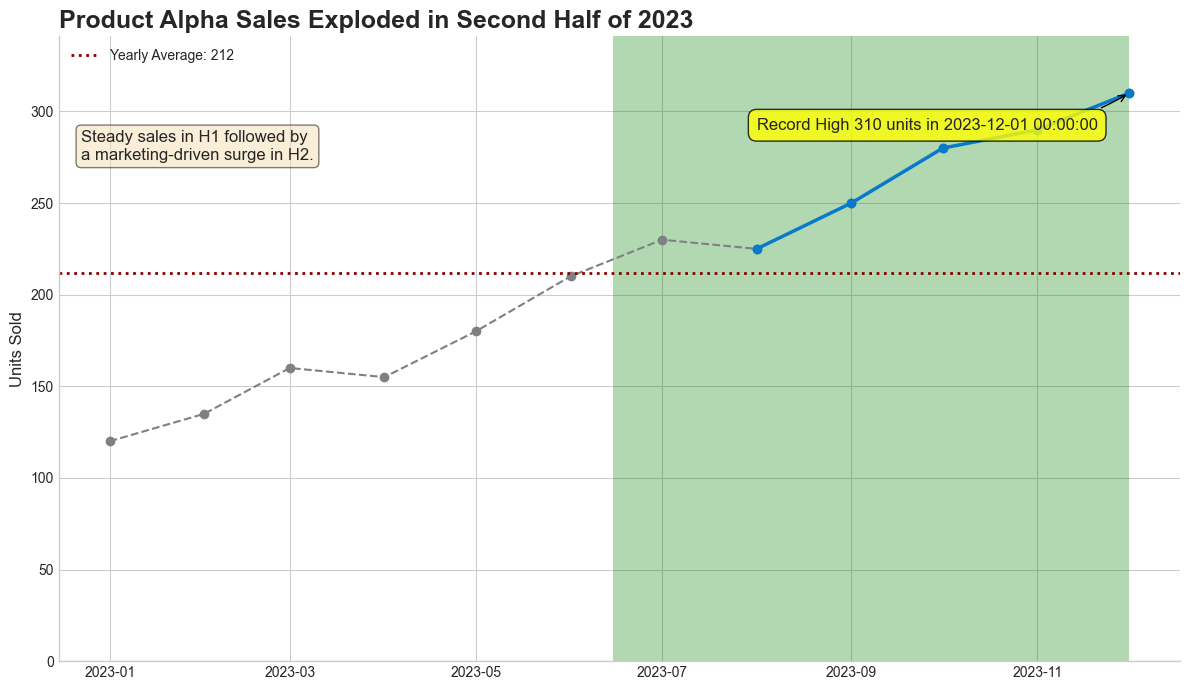

In [8]:
fig , ax = plt.subplots(figsize=(12,7))
ax.plot(data.index, data.values, color='gray', marker='o', linestyle='--', label='_nolegend_')

growth_period = data.loc['2023-08-01':]
ax.plot(growth_period.index , growth_period.values, color='#077ACC',marker='o',linewidth=2.5)


# High light the second part of the year
h1_end = pd.to_datetime('2023-06-15')
ax.axvspan(h1_end , data.index.max() , facecolor="g" , alpha=0.3)


# Add a reference line for the average
average_sales = data.mean()
ax.axhline(average_sales, color='darkred', linestyle=':', linewidth=2, label=f'Yearly Average: {average_sales:.0f}')

peak_month = data.idxmax()
peak_val = data.max()


ax.annotate(
    f'Record High {peak_val} units in {peak_month}',
    xy = (peak_month,peak_val),
    xytext=(peak_month - pd.DateOffset(months=4) , peak_val-20),
    arrowprops=dict(arrowstyle='->',connectionstyle="arc3,rad=.2",color='black'),
    fontsize= 12,
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="black", lw=1, alpha=0.8)

)

ax.set_title('Product Alpha Sales Exploded in Second Half of 2023', fontsize=18, fontweight='bold', loc='left')
ax.set_ylabel('Units Sold', fontsize=12)
ax.set_ylim(0, data.max() * 1.1)
ax.spines[['top', 'right']].set_visible(False)

# Add a text box for the story summary
ax.text(0.02, 0.85, 'Steady sales in H1 followed by\na marketing-driven surge in H2.',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
fig.tight_layout()
plt.show()

fig.savefig('magazine_quality_sales_chart.png', dpi=300)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
['Adelie' 'Chinstrap' 'Gentoo']


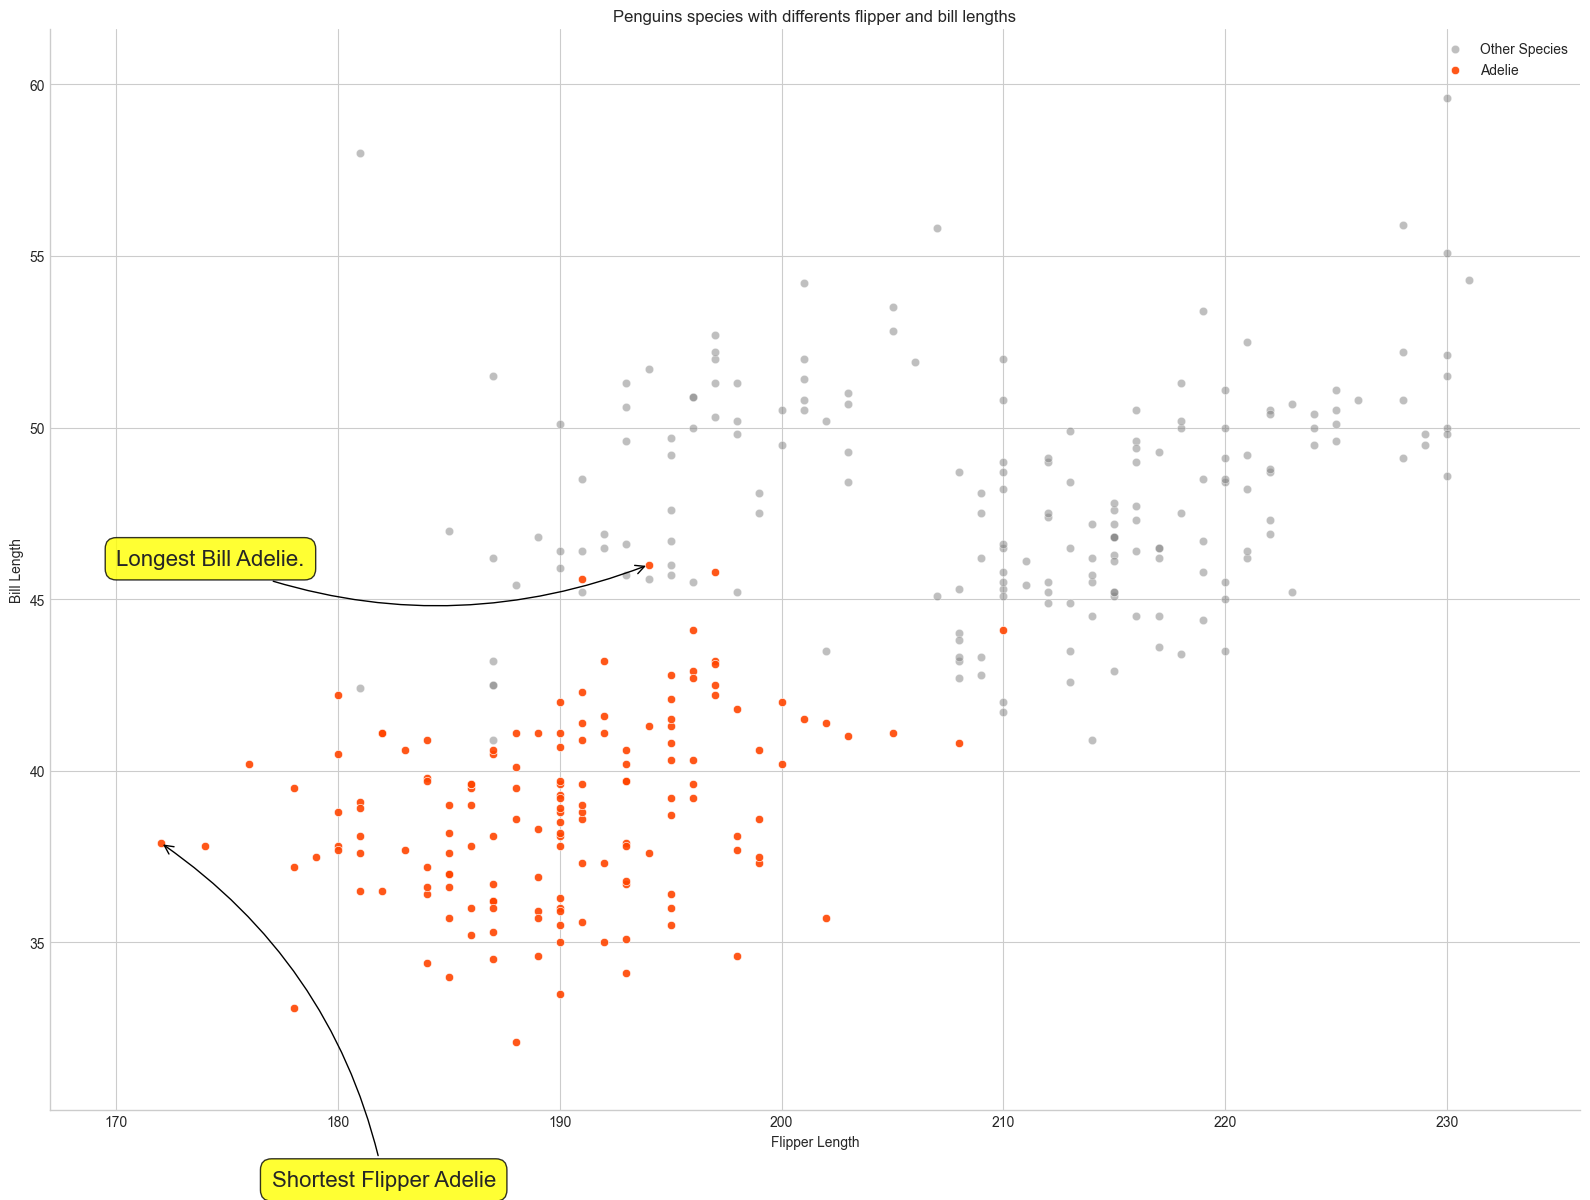

In [39]:
fig ,ax = plt.subplots(figsize=(16,12))
data = sns.load_dataset('penguins')

data.info()

print(data['species'].unique())

# scatter = sns.scatterplot(data=data, x='flipper_length_mm', y='bill_length_mm', ax=ax,hue='species',sizes=(20, 200),alpha=0.7)
# # ax.scatter(x= data['bill_length_mm'] , 
# #            y = data['flipper_length_mm'],
# #            marker='o',
# #            color='royalblue',
# #            edgecolors='black',
# #            alpha=0.6,
# #             s =50 )   # s is for size  

other_species = data[data['species'] != 'Adelie']
adelie_species = data[data['species'] == 'Adelie']

# 1. Plot the context first (Level 2)
sns.scatterplot(data=other_species, x='flipper_length_mm', y='bill_length_mm',
                color='gray', alpha=0.5, ax=ax, label='Other Species')

# 2. Plot the main story on top (Level 1)
sns.scatterplot(data=adelie_species, x='flipper_length_mm', y='bill_length_mm',
                color='orangered', alpha=0.9, ax=ax, label='Adelie')

ax.legend() # This will now show 'Other Species' and 'Adelie'

adelie = data[data['species'] == 'Adelie']
max_bill_length_index = adelie['bill_length_mm'].idxmax()
max_flipper_length_index = adelie['flipper_length_mm'].idxmax()
max_bill_length = adelie['bill_length_mm'][max_bill_length_index]
max_flipper_length_ = adelie['flipper_length_mm'][max_flipper_length_index]
# print(max_bill_length)

ax.annotate(
    f'Longest Bill Adelie.',
    xy = (adelie['flipper_length_mm'][max_bill_length_index],max_bill_length),
    xytext = (adelie['flipper_length_mm'][max_bill_length_index]-24 , max_bill_length),
    arrowprops=dict(arrowstyle='->',connectionstyle='arc3,rad=.2',color='black'),
    fontsize = 16,
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="black", lw=1, alpha=0.8)
)

shortest_flipper_index = adelie['flipper_length_mm'].idxmin() # Use idxmin() for minimum!

# 2. Get the coordinates of that specific penguin
sf_flipper_len = adelie.loc[shortest_flipper_index, 'flipper_length_mm'] # x-coord
sf_bill_len = adelie.loc[shortest_flipper_index, 'bill_length_mm']    # y-coord

# 3. Now, create the second annotation with these NEW coordinates
ax.annotate(
    'Shortest Flipper Adelie',
    xy=(sf_flipper_len, sf_bill_len),
    xytext=(sf_flipper_len + 5, sf_bill_len - 10), # Adjust text position as needed
    arrowprops=dict(arrowstyle='->',connectionstyle='arc3,rad=.2',color='black'),
    fontsize = 16,
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="black", lw=1, alpha=0.8)

)

ax.set_title("Penguins species with differents flipper and bill lengths")
ax.set_xlabel("Flipper Length")
ax.set_ylabel("Bill Length")
ax.spines[['top', 'right']].set_visible(False)

x_min, x_max = data['flipper_length_mm'].min(), data['flipper_length_mm'].max()
y_min, y_max = data['bill_length_mm'].min(), data['bill_length_mm'].max()
ax.set_xlim(x_min - 5, x_max + 5)
ax.set_ylim(y_min - 2, y_max + 2)

ax.legend()
fig.tight_layout()
plt.show()

In [40]:
longest_flipper_penguin_index = data['flipper_length_mm'].idxmax()
penguin_with_longest_flipper = data.loc[longest_flipper_penguin_index]
print("--- Penguin with the Longest Flipper Overall ---")
print(penguin_with_longest_flipper)

--- Penguin with the Longest Flipper Overall ---
species              Gentoo
island               Biscoe
bill_length_mm         54.3
bill_depth_mm          15.7
flipper_length_mm     231.0
body_mass_g          5650.0
sex                    Male
Name: 283, dtype: object


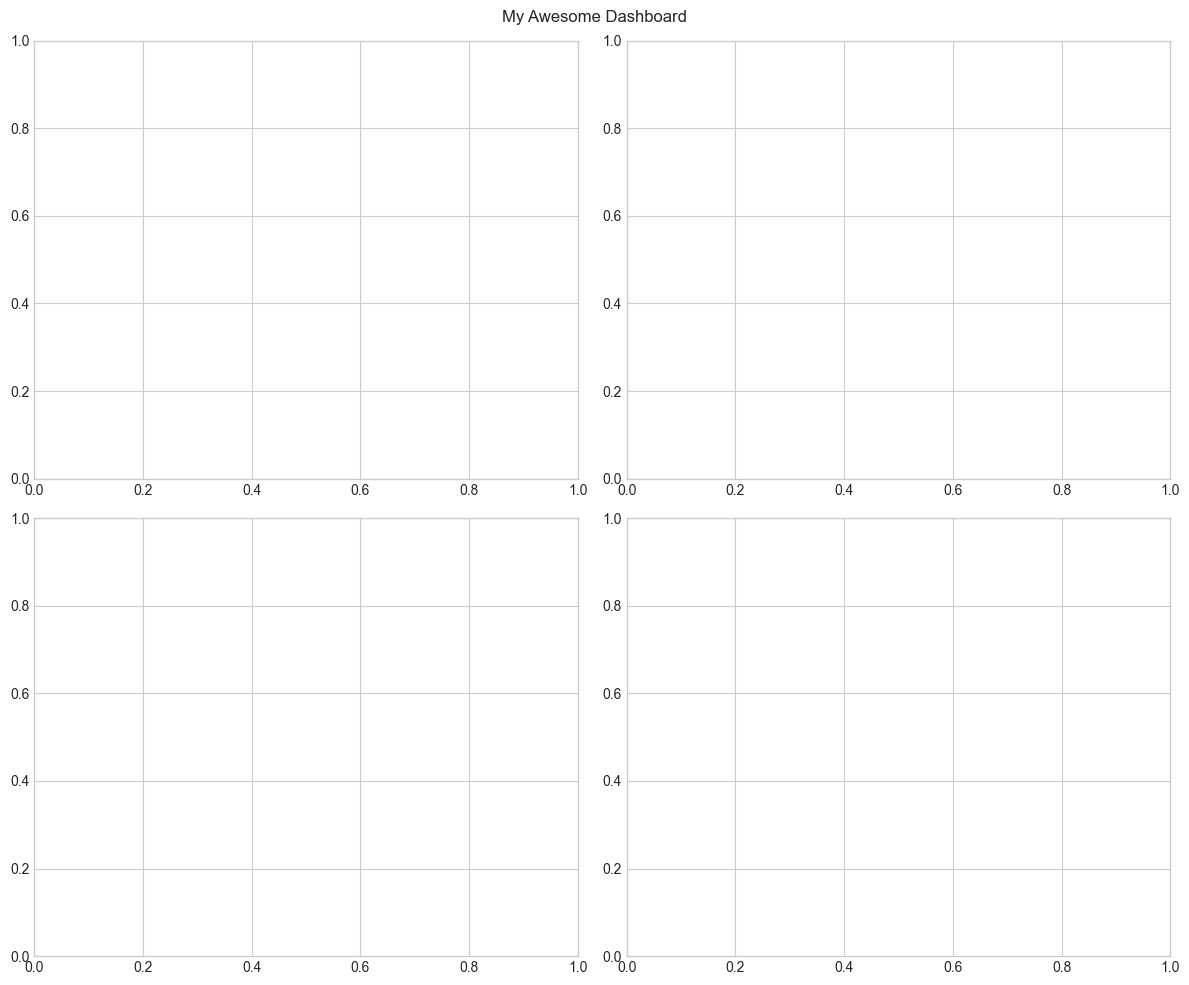

In [46]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

ax1 = axes[0, 0] # Top-left
ax2 = axes[0, 1] # Top-right
ax3 = axes[1, 0] # Bottom-left
ax4 = axes[1, 1] # Bottom-right

fig.suptitle('My Awesome Dashboard')
fig.tight_layout()

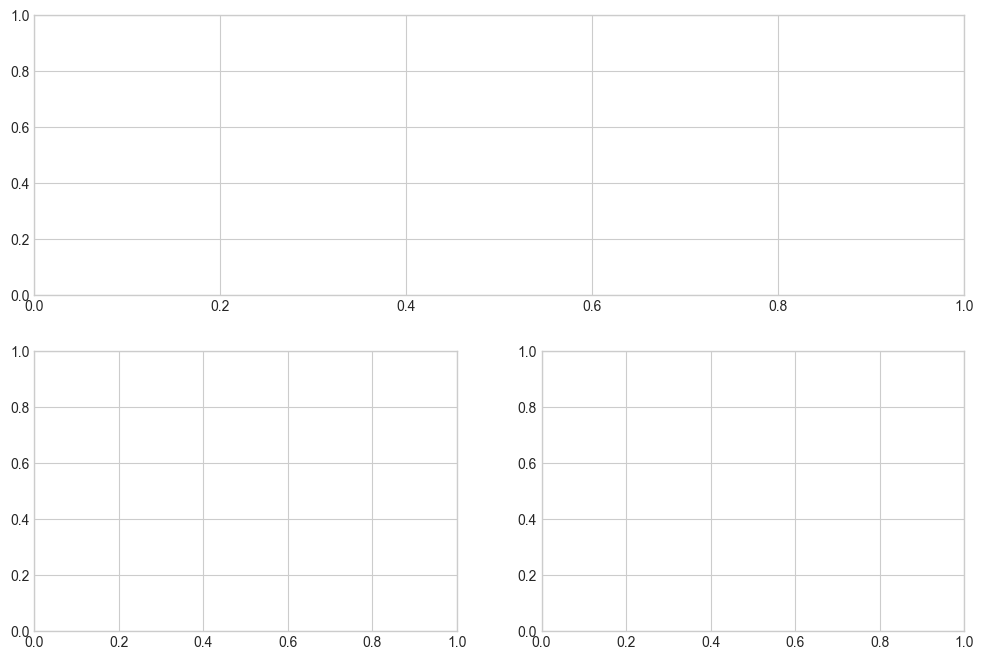

In [45]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(nrows=2, ncols=2, figure=fig)

# The 'hero' plot: takes up the entire top row
ax1 = fig.add_subplot(gs[0, :]) # The ':' means span all columns

# Two smaller plots on the bottom row
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Now plot on ax1, ax2, and ax3 as usual

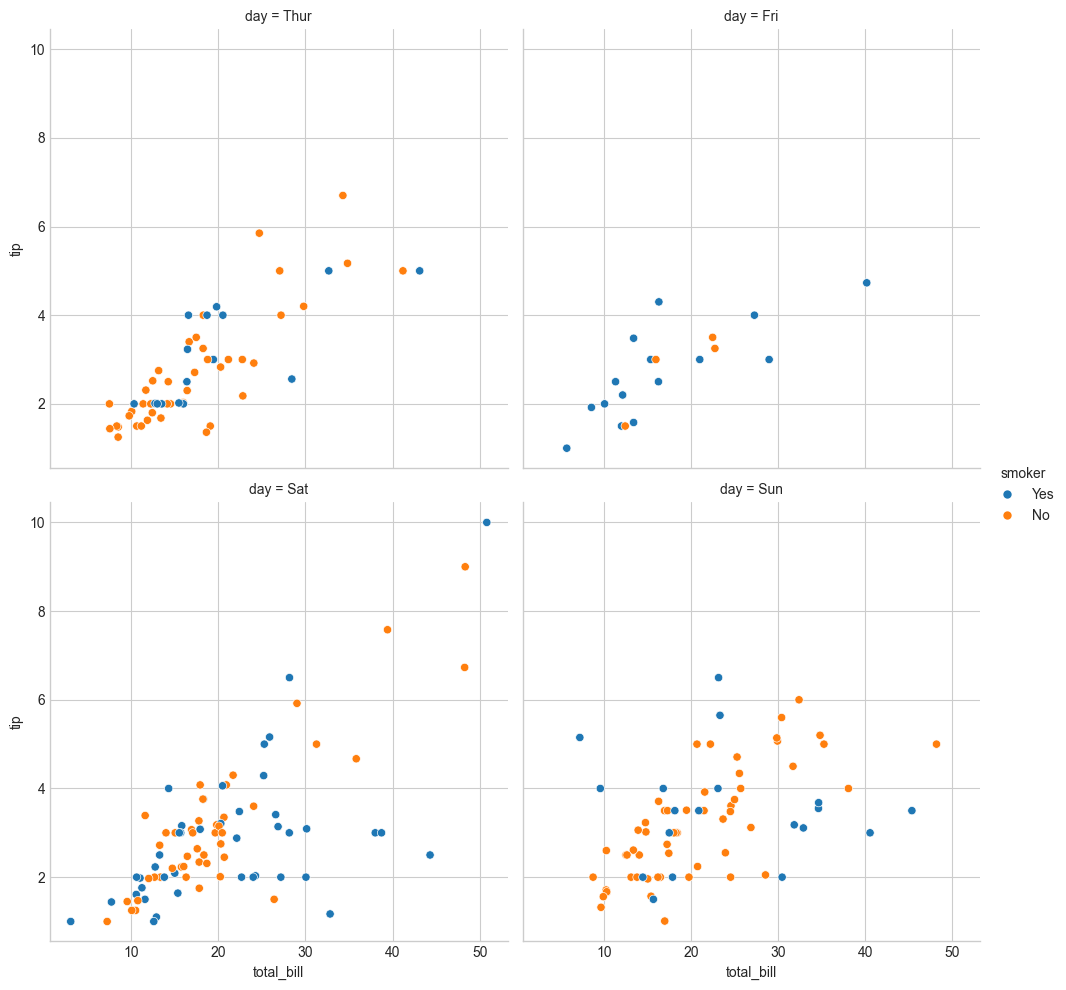

In [48]:
# This one line of code creates a full figure with a scatter plot for each day
# It's the equivalent of creating a 1x4 grid and looping through the days.
tips = sns.load_dataset('tips')
sns.relplot(
    data=tips, x='total_bill', y='tip',
    col='day',        # Creates a new plot in a new column for each day
    col_wrap=2,       # Wraps the columns after 2 plots
    hue='smoker',     # Hue is consistent across all facets
    kind='scatter'    # Can also be 'line'
)

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample data
data = {
    'Year': [1990, 2000, 2010, 2020] * 4,
    'Country': ['USA']*4 + ['China']*4 + ['India']*4 + ['Germany']*4,
    'CO2_emissions': [5.1, 5.8, 5.5, 4.8,  # USA
                      2.2, 4.6, 8.3, 10.7, # China
                      0.6, 0.9, 1.4, 2.5,  # India
                      1.0, 0.9, 0.8, 0.7], # Germany
    'GDP_per_capita_2020': [63000]*4 + [10500]*4 + [2000]*4 + [46000]*4
}
df = pd.DataFrame(data)

C:\Users\rajud\AppData\Local\Temp\ipykernel_10732\523424083.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_2020, x='Country', y='CO2_emissions', ax=ax_bottom_left, palette='Reds_r')


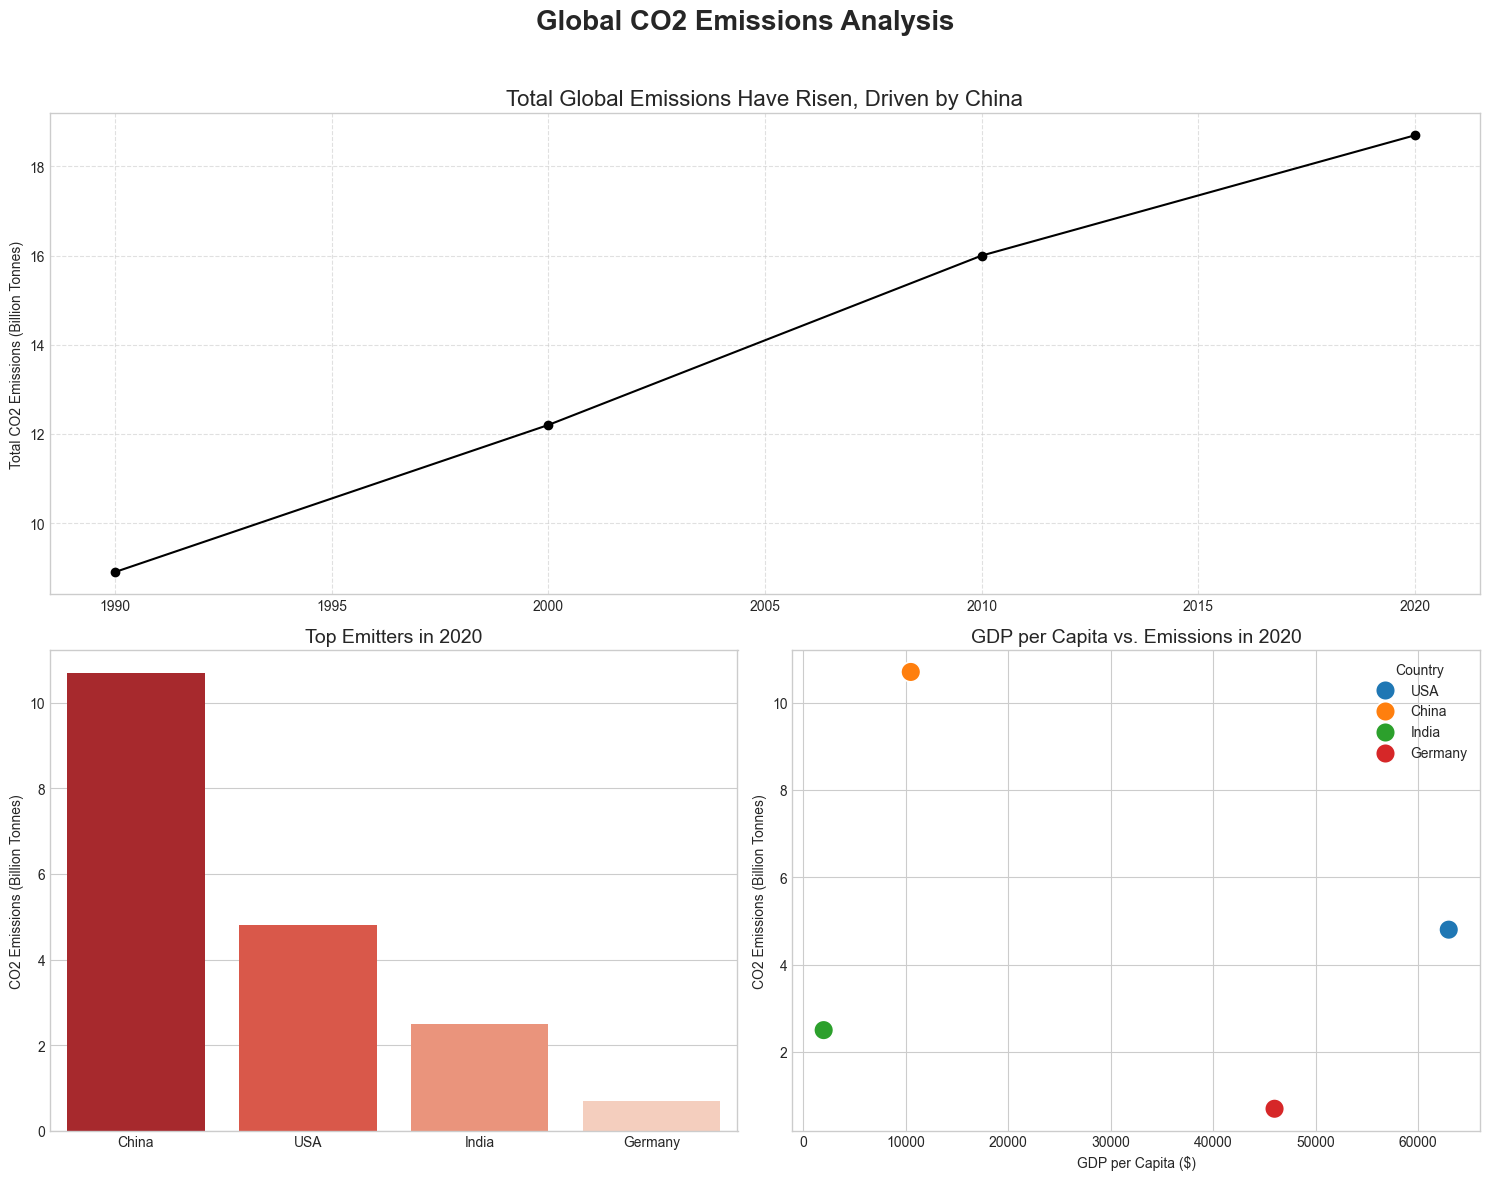

In [52]:
# --- Create the Custom Grid ---
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(2, 2) # A 2x2 grid specification

# Define the layout
ax_top = fig.add_subplot(gs[0, :]) # Top plot spans both columns
ax_bottom_left = fig.add_subplot(gs[1, 0]) # Bottom left
ax_bottom_right = fig.add_subplot(gs[1, 1]) # Bottom right

fig.suptitle('Global CO2 Emissions Analysis', fontsize=20, fontweight='bold')

# --- Plot 1: Global Trend (Top Plot) ---
global_trend = df.groupby('Year')['CO2_emissions'].sum()
ax_top.plot(global_trend.index, global_trend.values, marker='o', linestyle='-', color='black')
ax_top.set_title('Total Global Emissions Have Risen, Driven by China', fontsize=16)
ax_top.set_ylabel('Total CO2 Emissions (Billion Tonnes)')
ax_top.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Top Emitters in 2020 (Bottom Left) ---
data_2020 = df[df['Year'] == 2020].sort_values('CO2_emissions', ascending=False)
sns.barplot(data=data_2020, x='Country', y='CO2_emissions', ax=ax_bottom_left, palette='Reds_r')
ax_bottom_left.set_title('Top Emitters in 2020', fontsize=14)
ax_bottom_left.set_xlabel(None)
ax_bottom_left.set_ylabel('CO2 Emissions (Billion Tonnes)')

# --- Plot 3: GDP vs. Emissions (Bottom Right) ---
data_2020_gdp = df[df['Year'] == 2020]
sns.scatterplot(data=data_2020_gdp, x='GDP_per_capita_2020', y='CO2_emissions', hue='Country', s=200, ax=ax_bottom_right)
ax_bottom_right.set_title('GDP per Capita vs. Emissions in 2020', fontsize=14)
ax_bottom_right.set_xlabel('GDP per Capita ($)')
ax_bottom_right.set_ylabel('CO2 Emissions (Billion Tonnes)')
ax_bottom_right.legend(title='Country')

# --- Final Polish ---
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
fig.savefig('co2_dashboard.png', dpi=300)

In [63]:
data = sns.load_dataset('titanic')
data.info()

print(data['survived'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    

survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


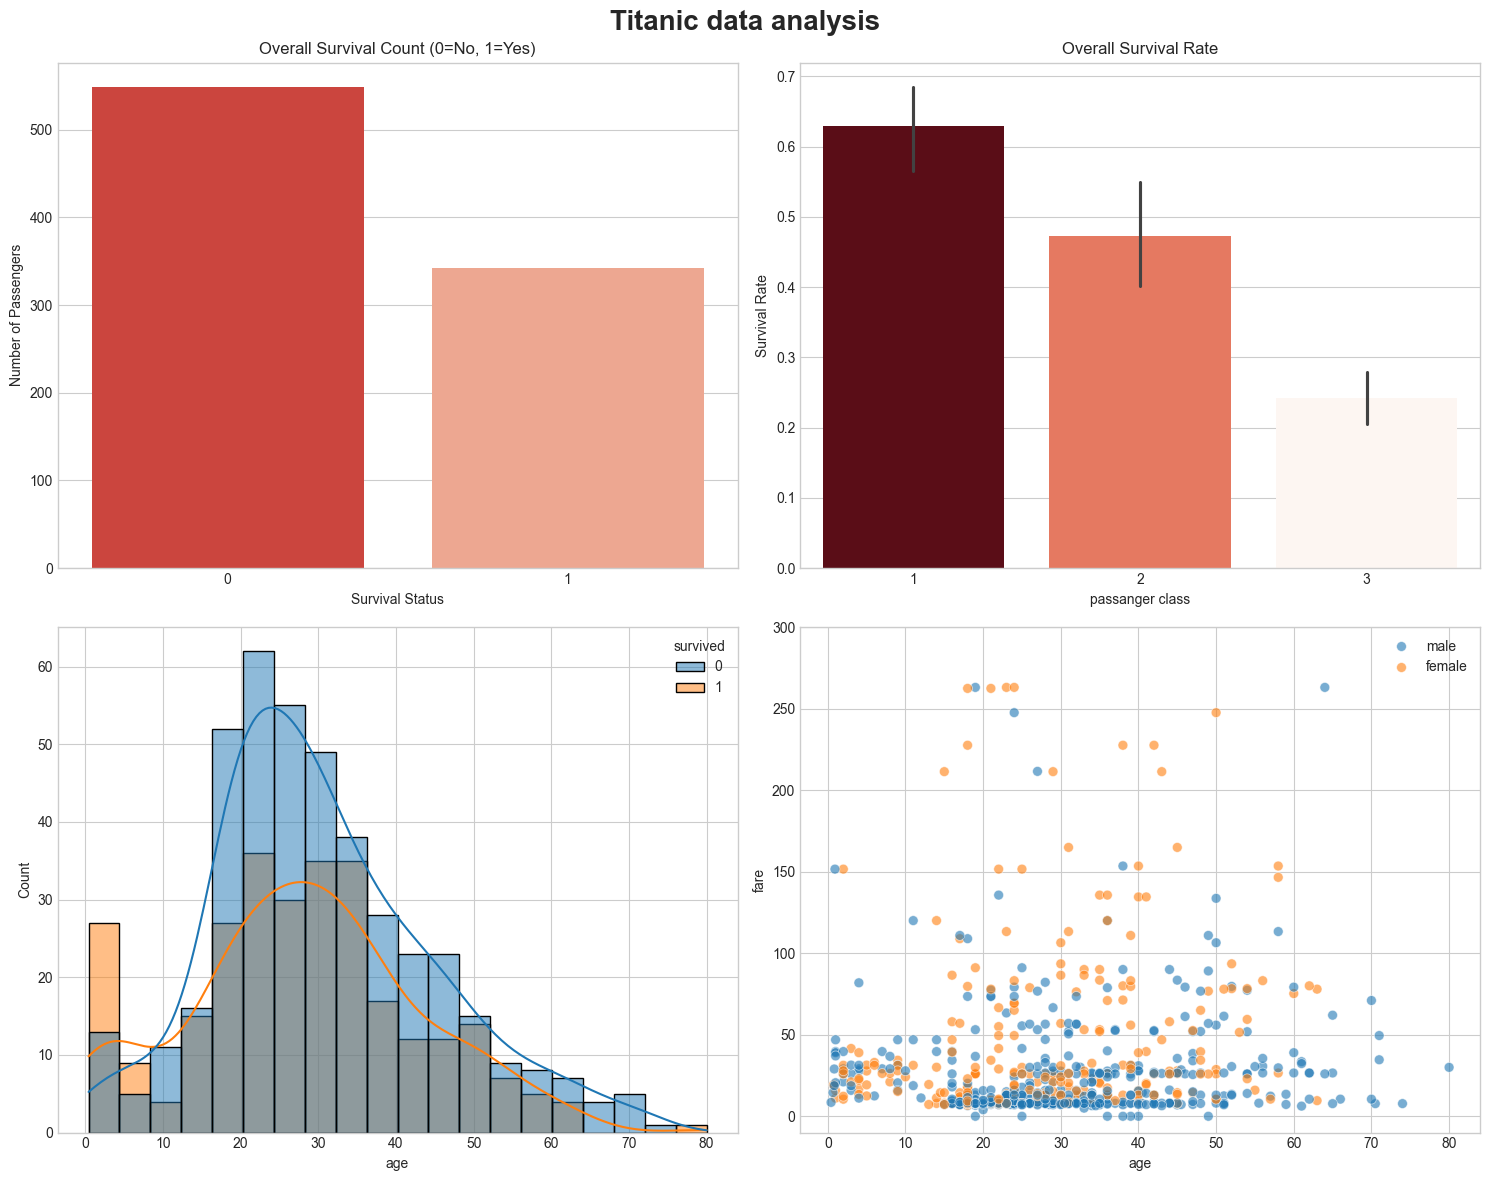

In [125]:
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(2, 2)

top_left  = fig.add_subplot(gs[0,0])
top_right = fig.add_subplot(gs[0,1])
bottom_left = fig.add_subplot(gs[1,0])
bottom_right = fig.add_subplot(gs[1,1])

# survived = data['survived'].sum()
survival_counts = data['survived'].value_counts()
survived = survival_counts[1]
not_survived = survival_counts[0]

fig.suptitle('Titanic data analysis', fontsize=20, fontweight='bold')
sns.barplot(x=survival_counts.index, y=survival_counts.values, ax=top_left,palette='Reds_r',legend=False,hue=survival_counts.index)
# sns.countplot(data=data , x='survived', ax = top_left)
top_left.set_title('Overall Survival Count (0=No, 1=Yes)')
top_left.set_xlabel('Survival Status')
top_left.set_ylabel('Number of Passengers')

survival_counts_by_class = data.groupby('pclass')['survived'].value_counts().unstack()
print(survival_counts_by_class)
sns.barplot(data= data , x='pclass' ,y='survived', ax=top_right,palette='Reds_r',hue='pclass' , legend=False )
top_right.set_title('Overall Survival Rate')
top_right.set_xlabel('passanger class')
top_right.set_ylabel('Survival Rate')

survivors = data[data['survived'] == 1]['age'].dropna()
non_survivors = data[data['survived'] == 0]['age'].dropna()

# sns.kdeplot(data=survivors, ax=bottom_left, label='Survived', color='green', alpha=0.7)
# sns.kdeplot(data=non_survivors, ax=bottom_left, label='Did Not Survive', color='red', alpha=0.7)

sns.histplot(
    data=data,
    x='age',
    hue='survived',  # <-- This is the key! It automatically splits the data.
    kde=True,        # Overlay a KDE for a smooth line.
    ax=bottom_left
)

# sns.kdeplot(
#     data=data,
#     x='age',
#     hue='survived',
#     fill=True,       # The `fill=True` makes it look like your original plot.
#     common_norm=False, # Important for comparing shapes
#     ax=bottom_right
# )

# sns.violinplot(data=data, ax=bottom_right, x='survived', y='age',palette={0:'red' , 1:'green'},hue='survived',inner='box')
# # violinplot y-axis  takes numerical distinct values and x-axis takes the categorical distinct values.

sns.scatterplot(data= data , x='age' , y = 'fare' , hue='sex',ax= bottom_right ,  alpha=0.6,  s=50  )
bottom_right.set_ylim(-10, 300)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# unstack(): Pivots an index level into columns, making the DataFrame wider.
# .stack(): Does the opposite. It takes columns and pivots them into an index level, making the DataFrame longer and skinnie

# This is more complex and not the recommended way for this plot.
# 1. Unstack the MultiIndex to create a DataFrame
counts_df = survival_counts_by_class.unstack()
# print(counts_df) gives:
# survived      0    1
# pclass
# 1        80  136
# 2        97   87
# 3       372  119

# 2. Calculate the rate manually
counts_df['survival_rate'] = counts_df[1] / (counts_df[0] + counts_df[1])

# 3. Plot this new DataFrame
sns.barplot(x=counts_df.index, y=counts_df['survival_rate'], ax=ax2)